/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfolio_df['Allokationsdatum'] = pd.to_datetime(portfolio_df['Allokationsdatum'])
/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfolio_df['Allokationsdatum'] = pd.to_datetime(portfolio_df['Allokationsdatum'])
/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfol

15.0    -32200.591800
15.5    -30880.756800
16.0    -29560.921800
16.5    -28241.086800
17.0    -26921.251800
            ...      
97.5    283212.393029
98.0    285381.228029
98.5    287550.063029
99.0    289718.898029
99.5    291887.733029
Length: 170, dtype: float64


/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfolio_df['Allokationsdatum'] = pd.to_datetime(portfolio_df['Allokationsdatum'])
/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfolio_df['Allokationsdatum'] = pd.to_datetime(portfolio_df['Allokationsdatum'])
/var/folders/8w/_dz7163x5w787n01tfqqmms80000gp/T/ipykernel_99530/2639074002.py:16: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  portfol

<AxesSubplot: >

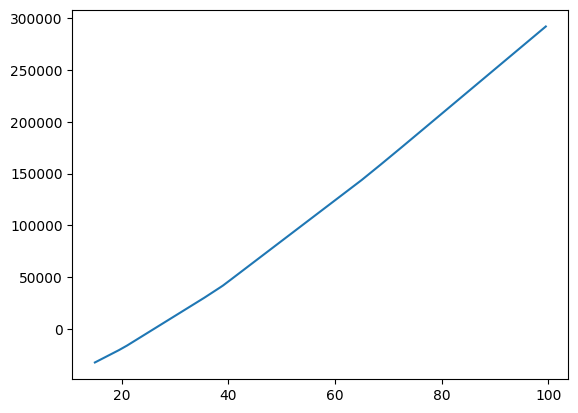

In [6]:
import numpy as np
import pandas as pd
from datetime import datetime

EINSTANDSPREIS = 'Ausübungspreis / Einstandspreis'

# Define the path to your CSV file
file_path = "~/Downloads/portfolio3.csv"
marktpreis = 26
# Read the CSV file into a pandas DataFrame
def calculate_profit(marktpreis):
    stock_price = pd.read_csv('~/Downloads/ZAL.DE.csv')
    portfolio_df = pd.read_csv(file_path)
    portfolio_df[EINSTANDSPREIS] = portfolio_df[EINSTANDSPREIS].fillna(0)
    #convert date to datetime
    portfolio_df['Allokationsdatum'] = pd.to_datetime(portfolio_df['Allokationsdatum'])
    portfolio_df.set_index('Allokationsdatum', inplace=True)
    stock_price['Date'] = pd.to_datetime(stock_price['Date'])
    #set index on date, take closed price, add column "strike_price" to portfolio_df
    stock_price.set_index('Date', inplace=True)
    #nearest
    stock_price = stock_price.resample('D').nearest()
    portfolio_df['strike_price'] = stock_price['Close']
    #For each day in portfolio_df, get the stock price and add it to the portfolio_df
    total_profit = 0
    RSU_rows =portfolio_df.query('Instrumententyp == "RSU (Restricted Stock Units)"')
    RSU_Profit = (RSU_rows['Zugewiesene Menge']*(marktpreis - RSU_rows[EINSTANDSPREIS])).sum()
    stock_rows = portfolio_df.query('Instrumententyp == "Aktien"')
    stock_Profit = (stock_rows['Verfügbare Menge']*(marktpreis - stock_rows[EINSTANDSPREIS])).sum()
    stock_value = (stock_rows['Verfügbare Menge']*(marktpreis)).sum()
    options_rows = portfolio_df.query('Instrumententyp == "Stock-Settled Appreciation Rights"')
    options_Profit = (options_rows['Zugewiesene Menge']*(marktpreis - options_rows[EINSTANDSPREIS]))
    options_options_rows = portfolio_df.query('Instrumententyp == "Optionen"')
    options_options_profit = options_options_rows['Zugewiesene Menge']*((marktpreis - options_options_rows["strike_price"]).clip(lower=0))
    total_profit = RSU_Profit + stock_Profit + options_Profit.sum() + options_options_profit.sum()
    return total_profit
#Make it into a pandas series and plot it
s= pd.Series([calculate_profit(marktpreis) for marktpreis in np.arange(15, 100, 0.5)], index=np.arange(15, 100, 0.5))
print(s)
s.plot()
    

In [ ]:
d